In [1]:
from google.colab import files
uploaded = files.upload()

Saving S001R03.edf to S001R03.edf


In [2]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.8 MB/s eta 0:00:00


Extracting EDF parameters from /content/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1057 samples (6.606 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


Using matplotlib as 2D backend.


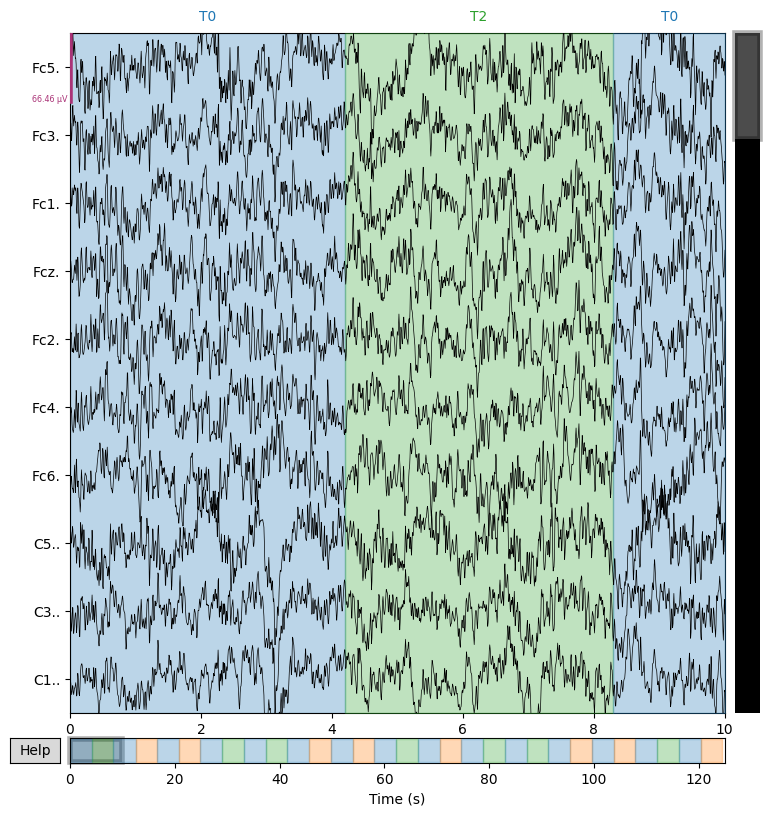

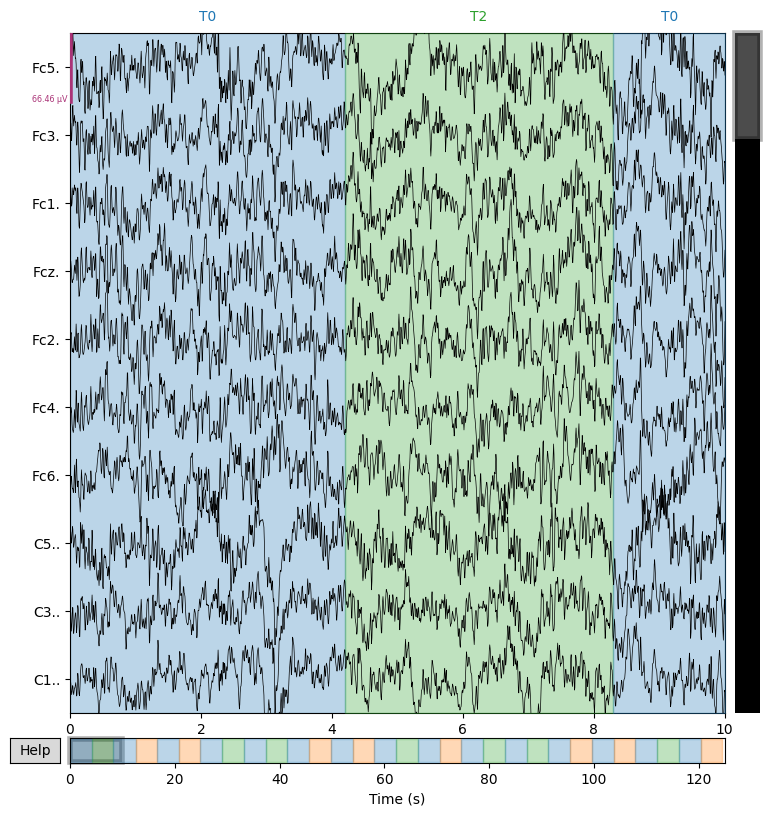

In [8]:
import mne

raw = mne.io.read_raw_edf("S001R03.edf", preload=True)
raw.set_eeg_reference('average')
raw.filter(0.5, 40)
raw.notch_filter(freqs=60)
raw.plot(scalings='auto', n_channels=10)

Segmentación y extracción de eventos

In [9]:
events, event_id_all = mne.events_from_annotations(raw)
print(event_id_all)

# Definir solo las tareas motoras (T1 y T2 en S001R03)
event_id = {
    'tarea_mano_derecha': event_id_all['T1'],  # usualmente 2
    'tarea_mano_izquierda': event_id_all['T2']  # usualmente 3
}

epochs = mne.Epochs(raw, events, event_id=event_id,
                    tmin=0, tmax=4, baseline=None, preload=True)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped


potencia por bandas EEG

In [10]:
import numpy as np
from mne.time_frequency import psd_array_welch

def extract_bandpower(epoch_data, sfreq, band, n_fft=256):
    psd, freqs = psd_array_welch(epoch_data, sfreq=sfreq, fmin=band[0], fmax=band[1], n_fft=n_fft)
    return np.mean(psd, axis=-1)

bands = {
    'delta': [0.5, 4],
    'theta': [4, 8],
    'alpha': [8, 13],
    'beta': [13, 30],
    'gamma': [30, 40]
}

sfreq = epochs.info['sfreq']
features = []

for epoch in epochs.get_data():
    epoch_feats = []
    for band_name, band_range in bands.items():
        bp = extract_bandpower(epoch, sfreq, band_range)
        epoch_feats.extend(bp)
    features.append(epoch_feats)

X = np.array(features)
y = epochs.events[:, -1]

Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective wind

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [12]:
import pandas as pd

feature_names = []
for band in bands:
    for ch in range(raw.info['nchan']):
        feature_names.append(f'{band}_ch{ch}')

df = pd.DataFrame(X, columns=feature_names)
df['label'] = y
df.head()

,delta_ch0,delta_ch1,delta_ch2,delta_ch3,delta_ch4,delta_ch5,delta_ch6,delta_ch7,delta_ch8,delta_ch9,...,gamma_ch55,gamma_ch56,gamma_ch57,gamma_ch58,gamma_ch59,gamma_ch60,gamma_ch61,gamma_ch62,gamma_ch63,label
0,1.012651e-10,4.329319e-11,5.345672e-11,7.517835e-11,3.054389e-11,2.363013e-11,3.836448e-11,6.895581e-11,4.814113e-11,7.719298e-11,...,3.022800e-12,2.084010e-12,1.421011e-12,1.643156e-12,3.766807e-12,2.246981e-12,2.271623e-12,3.986148e-12,4.477309e-12,3
1,8.319224e-11,2.298781e-11,4.040598e-11,7.149142e-11,6.270013e-11,3.774939e-11,3.427256e-11,7.664555e-11,2.876855e-11,3.769032e-11,...,2.765155e-12,2.375218e-12,2.545958e-12,2.128890e-12,2.935569e-12,2.592189e-12,3.030496e-12,4.124155e-12,6.363797e-12,2
2,5.429696e-11,3.314284e-11,2.668891e-11,4.351115e-11,4.137911e-11,2.727665e-11,4.815331e-11,9.041154e-11,5.433697e-11,4.961199e-11,...,1.873410e-12,1.621956e-12,1.710174e-12,2.090216e-12,3.279989e-12,1.692264e-12,2.365995e-12,3.154319e-12,4.893062e-12,2
3,3.089768e-11,5.180235e-11,5.461799e-11,9.503100e-11,5.043397e-11,2.265559e-11,4.036957e-11,9.888495e-11,3.616875e-11,4.213361e-11,...,1.904140e-12,1.569136e-12,1.549058e-12,1.856683e-12,3.490639e-12,1.501601e-12,1.940761e-12,2.497559e-12,3.855309e-12,3
4,8.446068e-11,5.332212e-11,4.830437e-11,4.767962e-11,3.966670e-11,4.736659e-11,9.182204e-11,2.474919e-10,1.415397e-10,1.380322e-10,...,2.709482e-12,2.115340e-12,1.415816e-12,1.728626e-12,3.374067e-12,2.159163e-12,2.512257e-12,4.013506e-12,5.782062e-12,3


Extracting EDF parameters from /content/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1057 samples (6.606 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


Fitting ICA to data using 64 channels (please be patient, this may take a while)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.2s finished


Selecting by number: 20 components
Fitting ICA took 4.5s.
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.


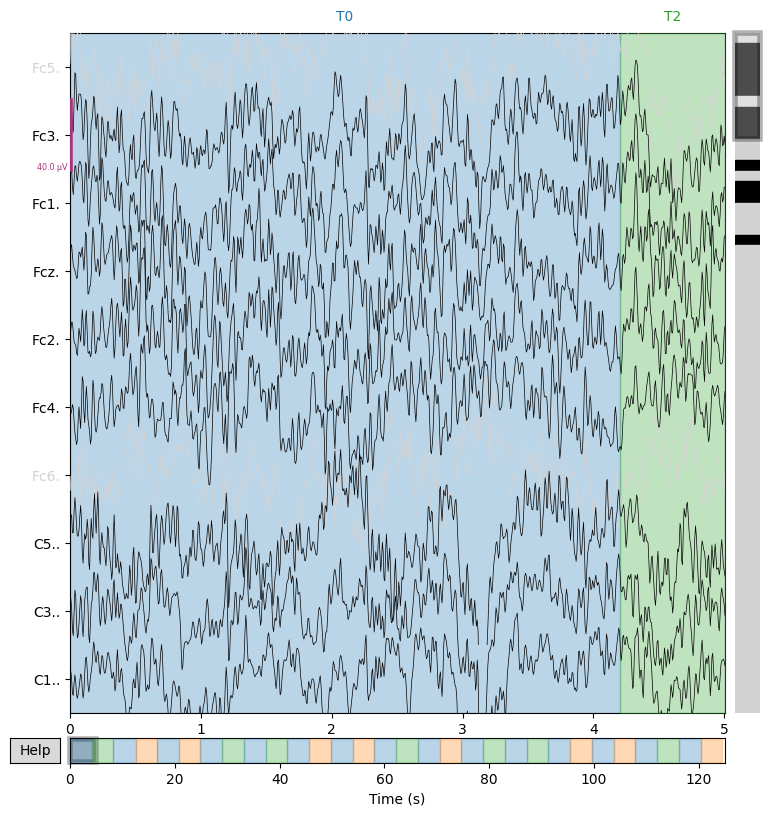

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped


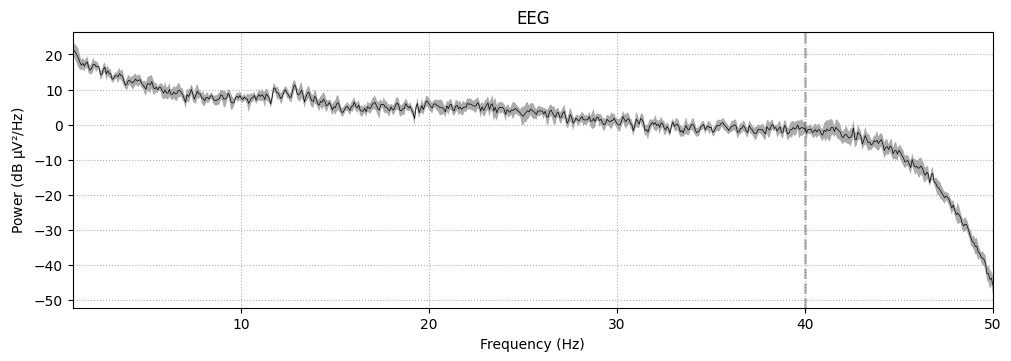

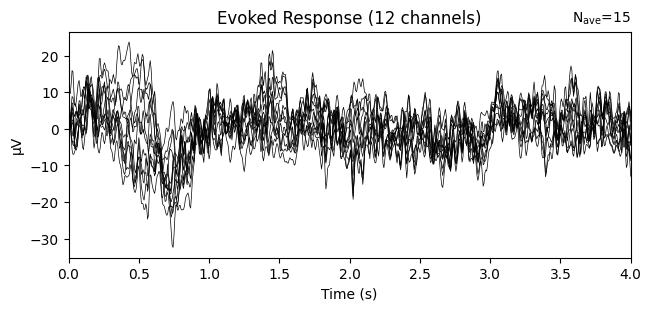

Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Effective window size : 1.600 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


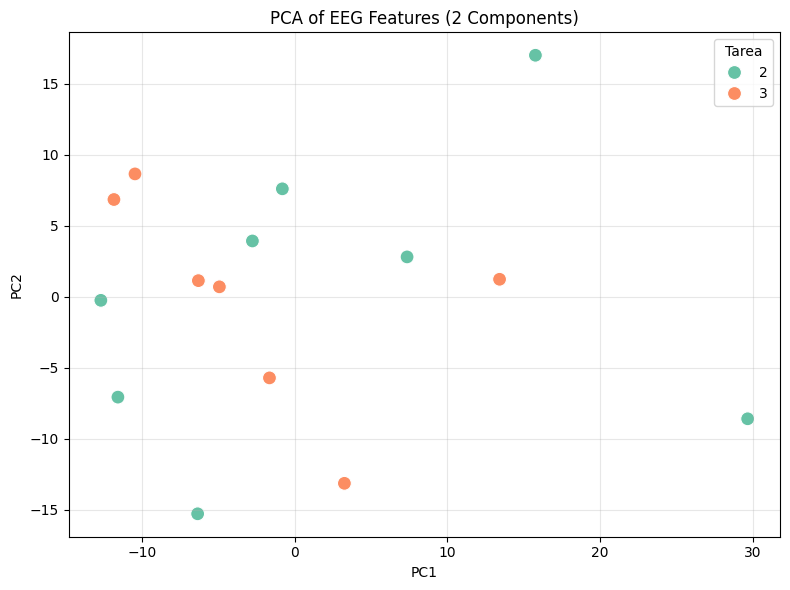

In [38]:
# Complete EEG preprocessing, artifact removal, integrated MNE analysis,
# feature extraction, feature engineering and PCA visualization

import numpy as np
import mne
from mne.preprocessing import ICA
import pywt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import kurtosis, skew

# 1. Load and preprocess raw EEG
file_path = '/content/S001R03.edf'
raw = mne.io.read_raw_edf(file_path, preload=True)
raw.set_eeg_reference('average')      # average reference
raw.filter(0.5, 40)                   # band-pass 0.5–40 Hz
raw.notch_filter(freqs=60)            # notch at 60 Hz

# 2. Remove artifacts via ICA
ica = ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)

# 2a. Remove EOG (blink) if any EOG channel exists
eog_chs = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
if eog_chs:
    eog_inds, _ = ica.find_bads_eog(raw, ch_name=eog_chs[0])
    ica.exclude = eog_inds
    raw_clean = ica.apply(raw.copy())
else:
    raw_clean = raw.copy()

# 2b. Remove muscle artifacts via high-frequency PSD ratio on ICA components
sources = ica.get_sources(raw_clean).get_data()
sf = raw_clean.info['sfreq']
muscle_inds = []
for idx, comp in enumerate(sources):
    psd_high, _  = mne.time_frequency.psd_array_welch(comp, sfreq=sf, fmin=30, fmax=45)
    psd_total, _ = mne.time_frequency.psd_array_welch(comp, sfreq=sf, fmin=1,  fmax=45)
    if psd_high.mean() / psd_total.mean() > 0.5:
        muscle_inds.append(idx)
ica.exclude += muscle_inds
raw_clean = ica.apply(raw_clean.copy())

# 3. Integrated MNE-Python analysis
# 3a. Detect bad channels via peak-to-peak criterion
ptp_threshold = 200e-6  # 200 µV, adjust as needed
data_eeg = raw_clean.get_data(picks='eeg')
ptp = np.ptp(data_eeg, axis=1)
bads = [raw_clean.ch_names[i] for i, val in enumerate(ptp) if val > ptp_threshold]
raw_clean.info['bads'] = bads

# 3b. Set montage and interpolate bads
montage = mne.channels.make_standard_montage('standard_1020')
raw_clean.set_montage(montage, on_missing='ignore')
try:
    raw_clean.interpolate_bads()
except ValueError:
    print("Warning: skipping bad-channel interpolation (no digitization points)")

# 3c. Temporal inspection
raw_clean.plot(n_channels=10, duration=5, title='Cleaned Raw EEG')

# 3d. Frequency inspection (PSD)
raw_clean.plot_psd(fmin=1, fmax=50, average=True, picks='eeg')

# 3e. Epochs & Evoked
events, event_id_all = mne.events_from_annotations(raw_clean)
event_id = {
    'tarea_mano_derecha': event_id_all.get('T1'),
    'tarea_mano_izquierda': event_id_all.get('T2')
}
epochs = mne.Epochs(raw_clean, events, event_id=event_id,
                    tmin=0, tmax=4, baseline=None, preload=True)
evoked = epochs.average()
evoked.plot(spatial_colors=True, titles='Evoked Response')

# Safe topomap plotting without digitization
times = np.linspace(0.1, 0.4, 5)
try:
    evoked.plot_topomap(times=times, ch_type='eeg', cmap='RdBu_r', sensors=False)
except Exception as e:
    print(f"Warning: could not plot topomap ({e})")

# 4. Prepare for feature extraction
sfreq = epochs.info['sfreq']

# 5. Feature extraction: bandpower + DWT
bands = {
    'delta': (0.5, 4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 40)
}

def extract_bandpower(epoch, band):
    psd, _ = mne.time_frequency.psd_array_welch(
        epoch, sfreq=sfreq, fmin=band[0], fmax=band[1], n_fft=256)
    return psd.mean(axis=-1)

def apply_dwt(ch_data):
    cA, cD = pywt.dwt(ch_data, 'db4')
    return cA.mean(), cD.mean()

features_bp = []
features_wt = []
for epoch in epochs.get_data():
    bp_feats = []
    for band in bands.values():
        bp_feats.extend(extract_bandpower(epoch, band))
    features_bp.append(bp_feats)
    wt_feats = []
    for ch in epoch:
        wt_feats.extend(apply_dwt(ch))
    features_wt.append(wt_feats)

X_bp = np.array(features_bp)
X_wt = np.array(features_wt)
X = np.hstack((X_bp, X_wt))
y = epochs.events[:, -1]

# 6. Feature engineering: statistics per epoch
def calc_stats(X):
    return {
        'mean':     np.mean(X, axis=1),
        'std':      np.std(X, axis=1),
        'max':      np.max(X, axis=1),
        'min':      np.min(X, axis=1),
        'kurtosis': kurtosis(X, axis=1),
        'skewness': skew(X, axis=1)
    }

stats = calc_stats(X)
df = pd.DataFrame(X, columns=[f'F{i+1}' for i in range(X.shape[1])])
for name, vals in stats.items():
    df[name] = vals

# 7. Normalize engineered features
scaler_feat = StandardScaler()
X_norm = scaler_feat.fit_transform(df)

# 8. PCA and visualization
pca = PCA(n_components=2)
pc = pca.fit_transform(X_norm)
pca_df = pd.DataFrame(pc, columns=['PC1', 'PC2'])
pca_df['Label'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='Set2', s=100)
plt.title('PCA of EEG Features (2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.legend(title='Tarea')
plt.tight_layout()
plt.show()


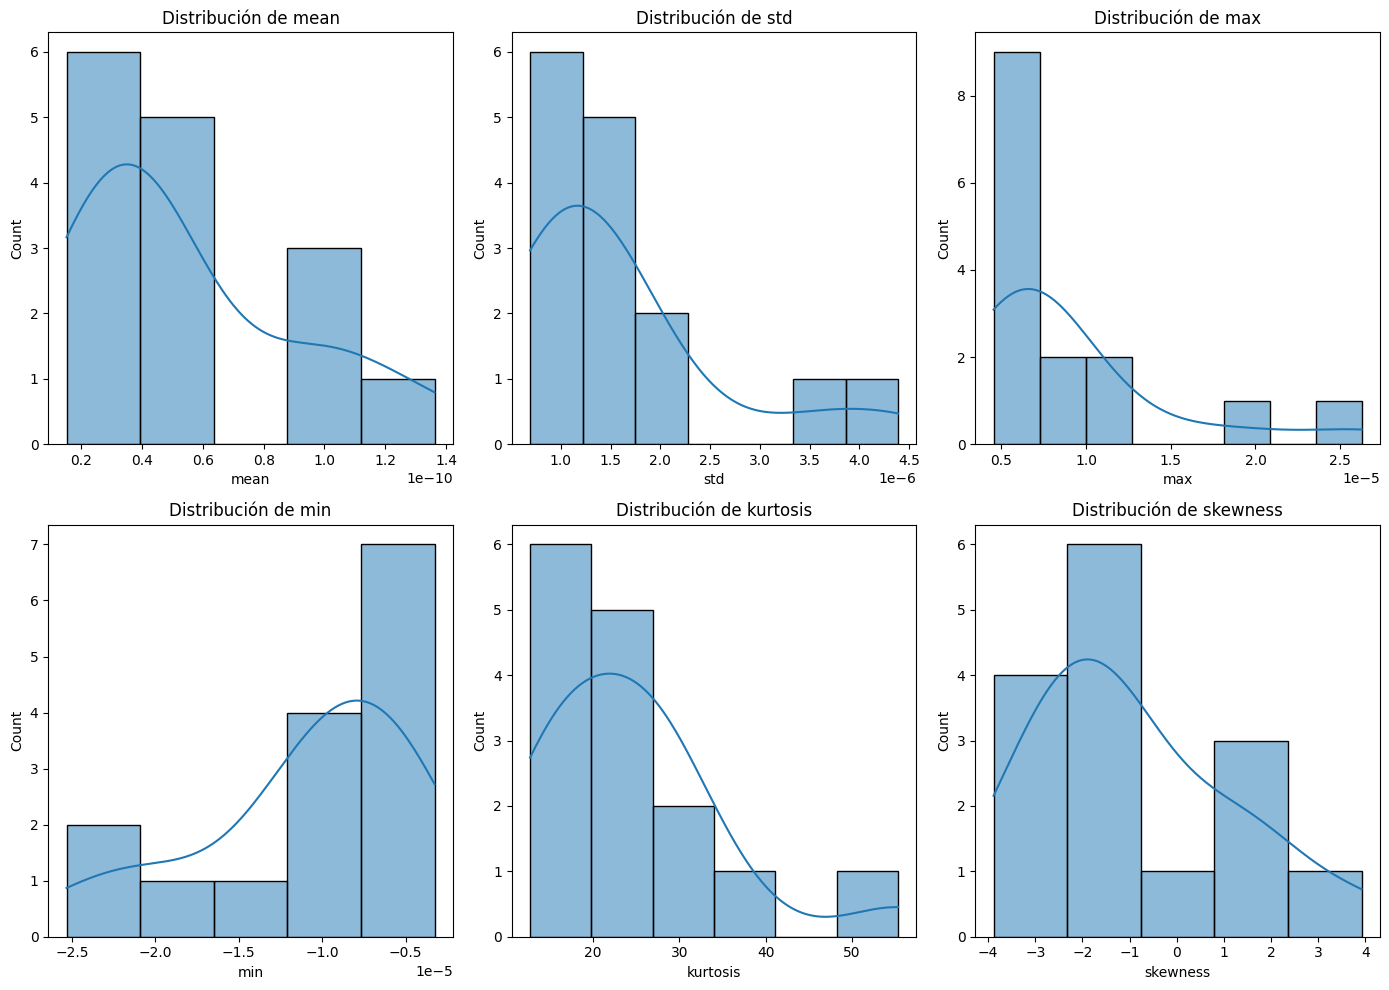

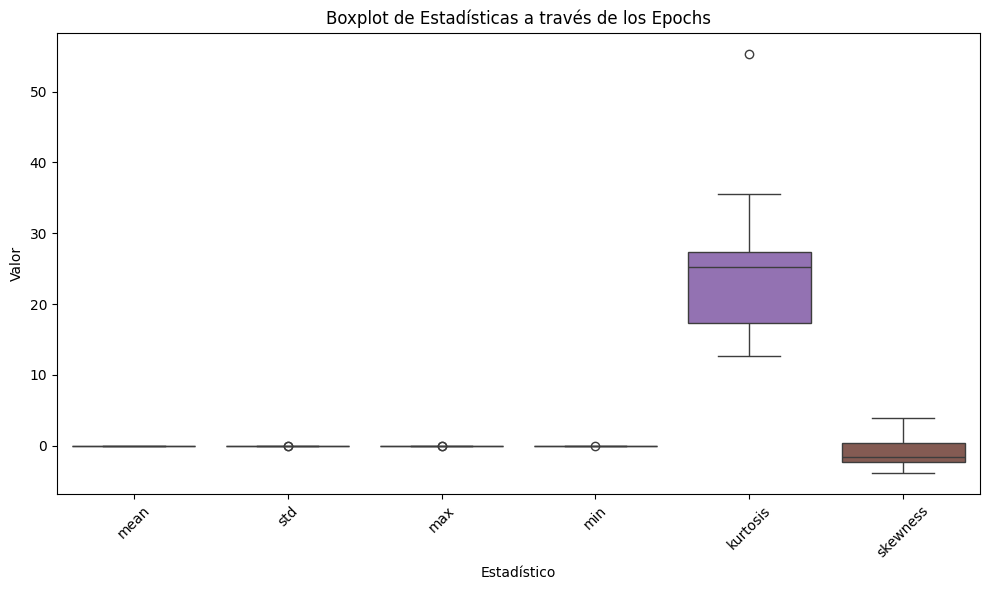

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame con las estadísticas calculadas para cada epoch
# Asumimos que se llama 'df' y contiene las columnas: mean, std, max, min, kurtosis, skewness
stats_cols = ['mean', 'std', 'max', 'min', 'kurtosis', 'skewness']

# 1. Histogramas con KDE para cada estadístico
plt.figure(figsize=(14, 10))
for i, col in enumerate(stats_cols):
    ax = plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# 2. Boxplot resumen de todos los estadísticos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[stats_cols])
plt.title('Boxplot de Estadísticas a través de los Epochs')
plt.xlabel('Estadístico')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


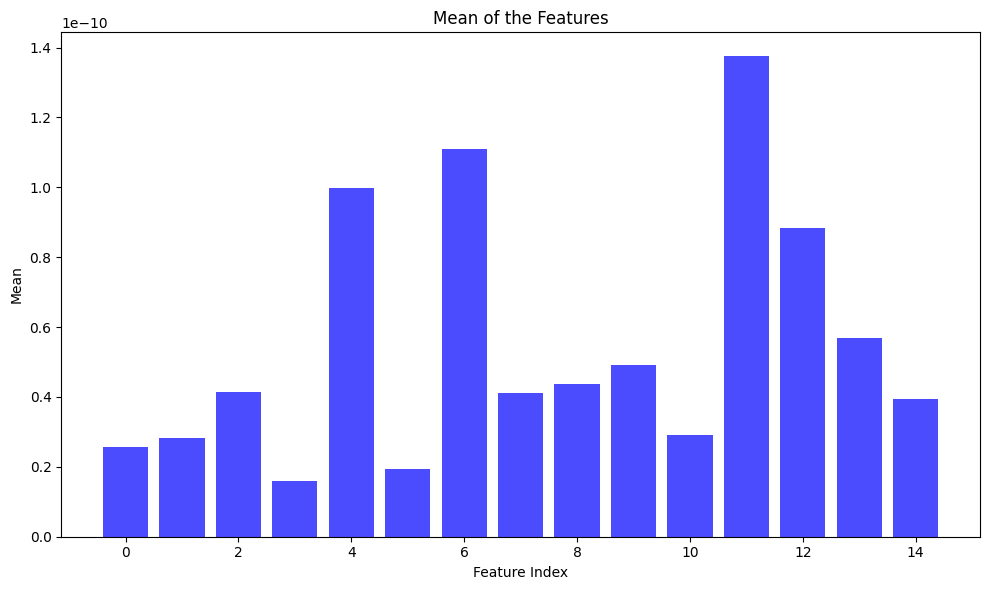

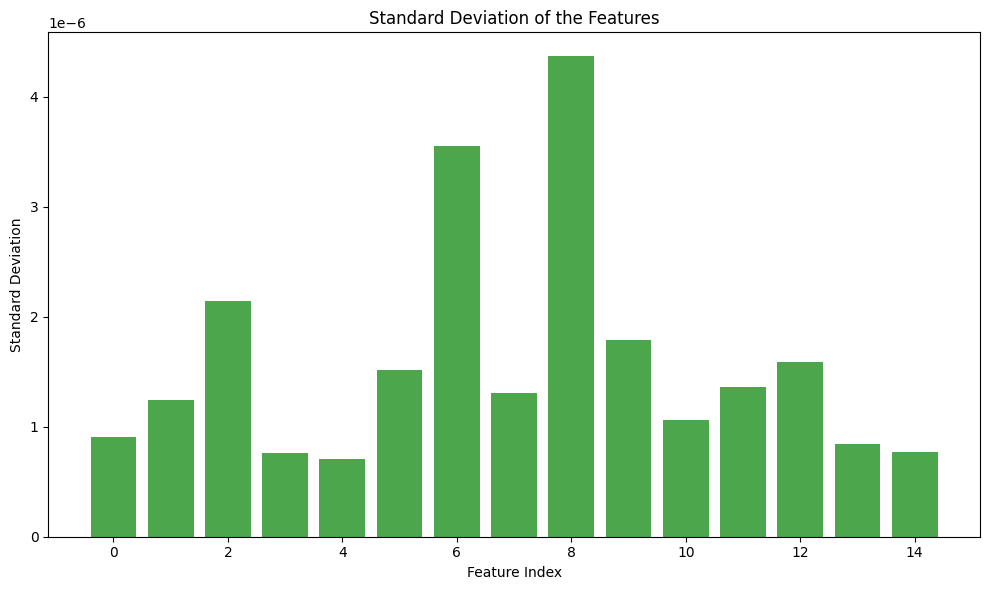

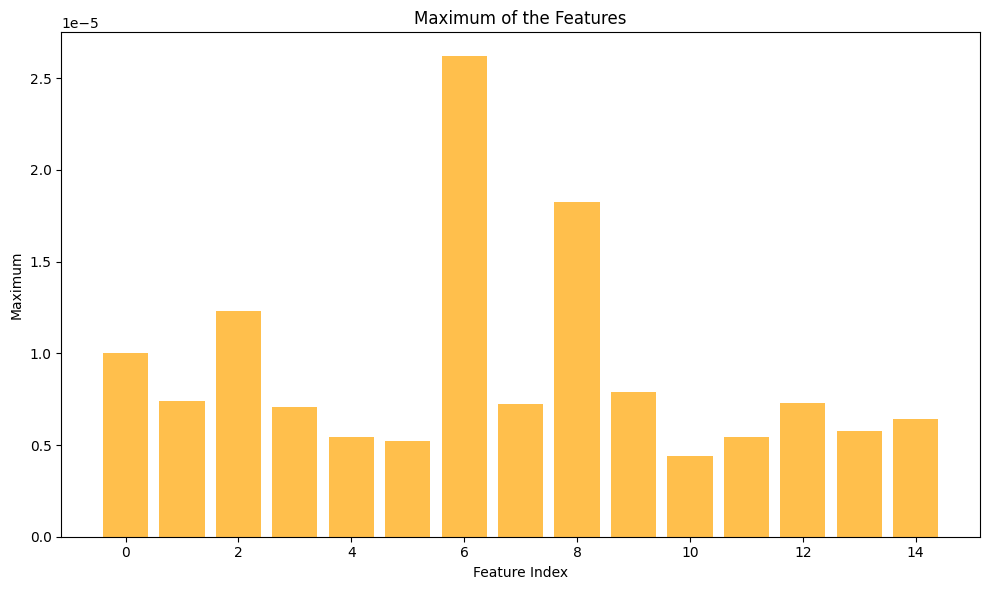

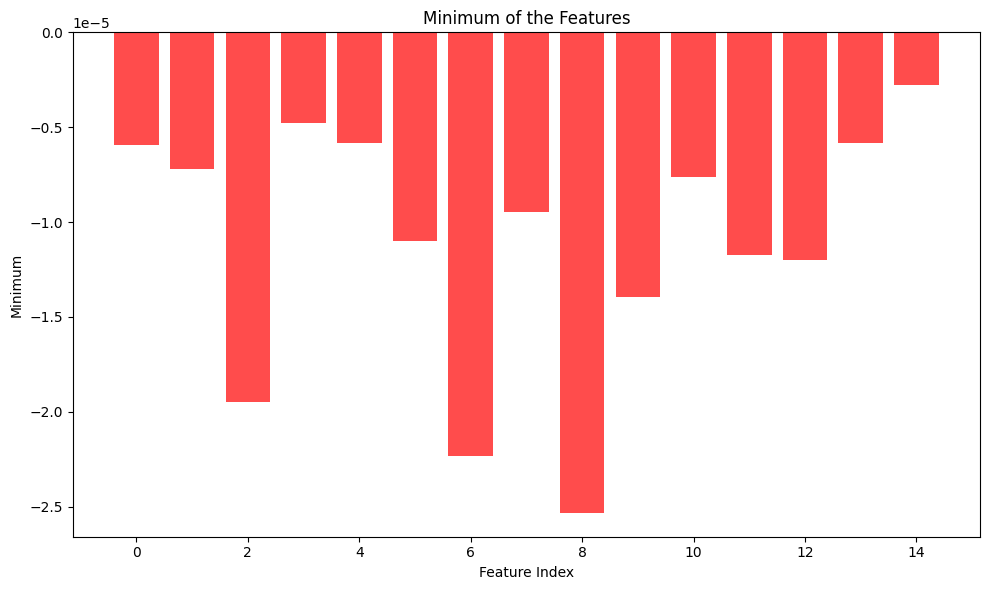

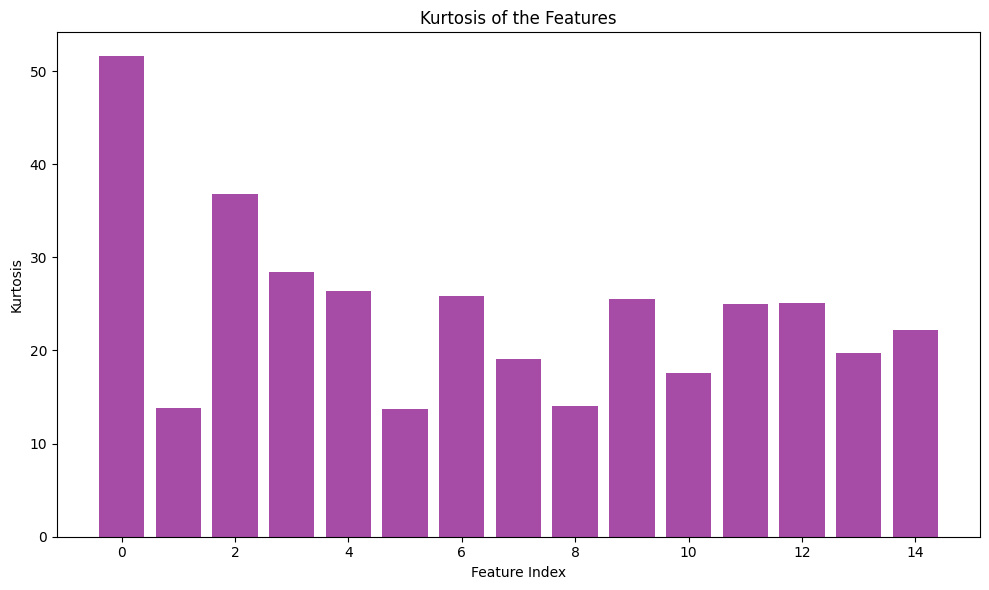

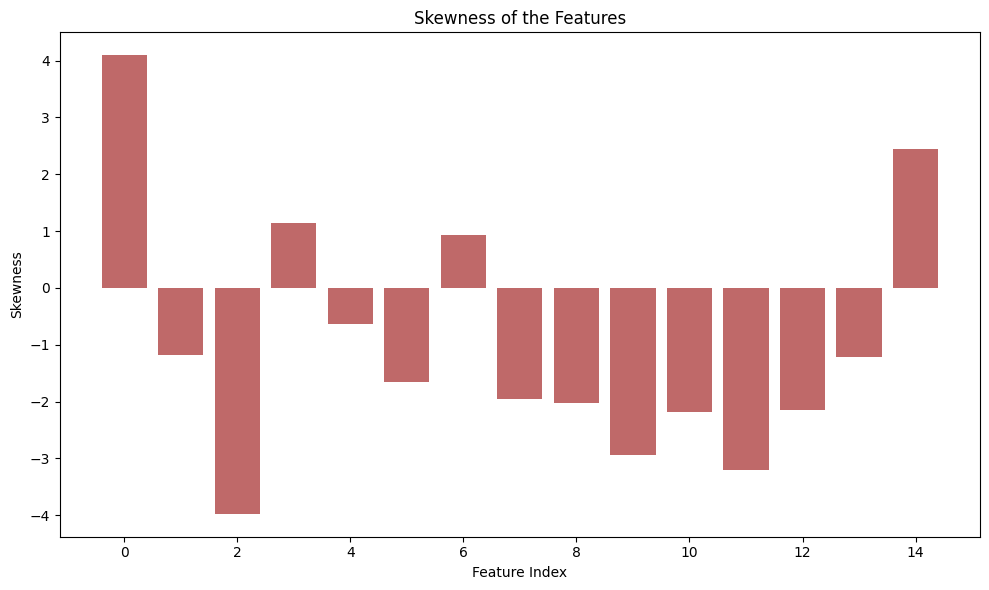

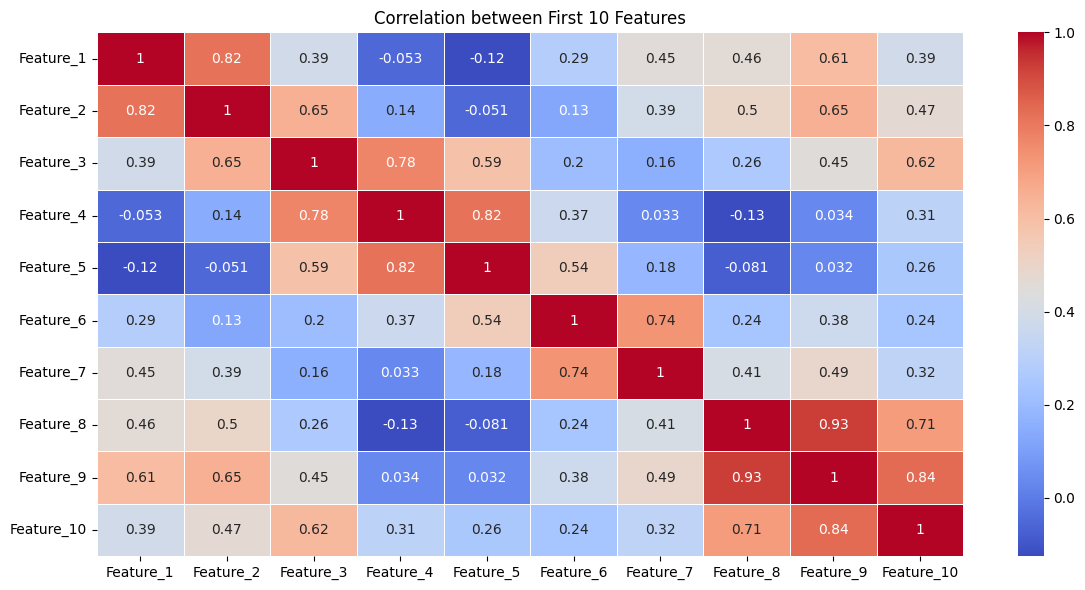

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes you have:
# - `feature_stats`: a dict with keys 'mean', 'std', 'max', 'min', 'kurtosis', 'skewness'
# - `feature_df`: a DataFrame with your feature columns

# 1. Bar plots for each statistic
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['mean'])), feature_stats['mean'], color='blue', alpha=0.7)
plt.title('Mean of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Mean')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['std'])), feature_stats['std'], color='green', alpha=0.7)
plt.title('Standard Deviation of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Standard Deviation')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['max'])), feature_stats['max'], color='orange', alpha=0.7)
plt.title('Maximum of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Maximum')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['min'])), feature_stats['min'], color='red', alpha=0.7)
plt.title('Minimum of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Minimum')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['kurtosis'])), feature_stats['kurtosis'], color='purple', alpha=0.7)
plt.title('Kurtosis of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Kurtosis')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_stats['skewness'])), feature_stats['skewness'], color='brown', alpha=0.7)
plt.title('Skewness of the Features')
plt.xlabel('Feature Index')
plt.ylabel('Skewness')
plt.tight_layout()
plt.show()

# 2. Correlation heatmap for the first 10 original features
plt.figure(figsize=(12, 6))
sns.heatmap(feature_df.iloc[:, :10].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between First 10 Features')
plt.tight_layout()
plt.show()
